In [2]:
import numpy as np
%pip install matplotlib
%pip install pdr
import matplotlib.pyplot as plt
from os import pathimport sys
import os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [27]:
import pdr
import logging
from dataset.processing import handle_irregular_data

# Set up a simple logger
logger = logging.getLogger('notebook')
logger.setLevel(logging.INFO)

# f = 's_02685401_rgram.xml'
f = 's_02685401_sim.xml'

# Load and parse the label file
data = pdr.read(f)
print(f'The keys are {data.keys()}')


The keys are ['Left_Side_Clutter_Simulation', 'Right_Side_Clutter_Simulation', 'Combined_Clutter_Simulation', 'label']


TypeError: list indices must be integers or slices, not str

In [28]:
# Get the radargram data
R = data['Combined_Clutter_Simulation']
# R = data['MRO_SHARAD_US_Radargram']

# Handle irregular data using the mechanism from the main codebase
R = handle_irregular_data(R, f, logger)

N = R.shape[0]  # Line
M = R.shape[1]  # Sample
print(f"Data shape: {R.shape}")


KeyError: 'Sample'

In [29]:
eps = 1e-16
R = np.where(R <= 0, eps, R)
R = 20*np.log10(R)
#R = np.clip(R, -90, -10)

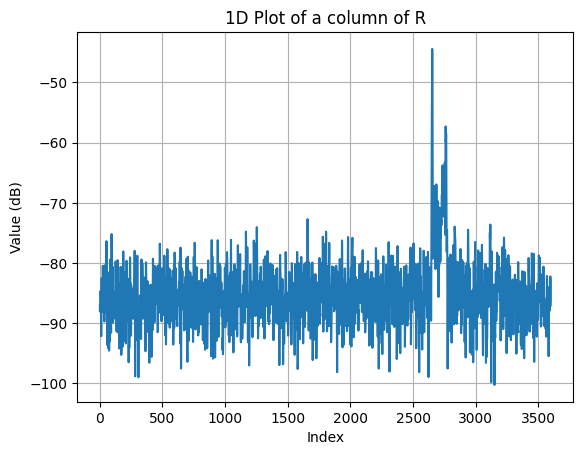

In [20]:
c = M//2

plt.plot(R[:,c])  # Plot the middle column of R
plt.title("1D Plot of a column of R")
plt.xlabel("Index")
plt.ylabel("Value (dB)")
plt.grid(True)
plt.show()

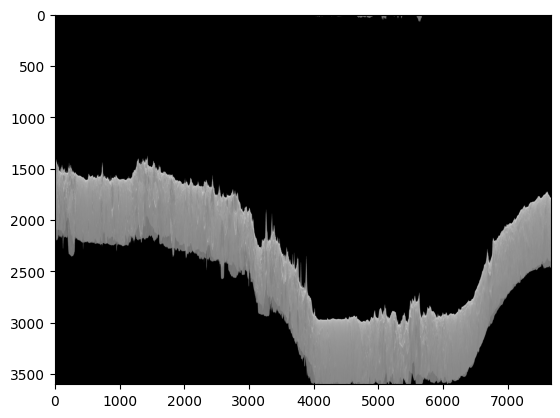

In [30]:
plt.imshow(R, cmap='gray', aspect='auto')

In [31]:
min_val = R.min()
max_val = R.max()
mean_val = R.mean()
std_val = R.std()

print(f"Min: {min_val}, \nMax: {max_val}, \nMean: {mean_val}, \nStd: {std_val}")

Min: -320.0, 
Max: -228.7895050048828, 
Mean: -309.98907470703125, 
Std: 20.694377899169922


In [ ]:
import ipywidgets as widgets


def plot_column(x):
    sorted_indices = np.argsort(R[:,x])[-10:]  # Get the indices of the 10 largest values
    largest_values = R[:,x][sorted_indices]  # Get the 10 largest values
    print("The 10 largest values are:", largest_values)
    print("Their corresponding indexes are:", sorted_indices)
    plt.imshow(R, cmap='gray', aspect='auto')
    # plt.plot([x, x], y, color="r", linewidth=3)
    plt.plot([x]*10, sorted_indices, 'o')
    plt.title(f"Column {x}")
    plt.xlabel("Index")
    plt.ylabel("Value (dB)")
    plt.grid(True)
    plt.show()
    
widgets.interactive(plot_column, x=widgets.IntSlider(min=0, max=M-1, step=1, value=c))

interactive(children=(IntSlider(value=2233, description='x', max=4466), Output()), _dom_classes=('widget-inter…

In [ ]:
import ipywidgets as widgets
import matplotlib.patches as patches


height = 256
width = 256


def calculate_box(x):
    left_edge = x - width//2
    right_edge = x + width//2
    
    if left_edge < 0:
        left_edge = 0
        right_edge = width
        x = width//2
    if right_edge > M:
        right_edge = M
        left_edge = M - width
        x = M - width//2
        
    y_current = R[:,x].argmax()  # Get the index of the maximum value in the column (i.e. the y-coordinate of the point)
    horizon_line = R[:,left_edge:right_edge].argmax(axis=0)  # Get the index of the maximum value inside the rectangle
    
    minimum_y = horizon_line.min()
    maximum_y = horizon_line.max()
    
    top_edge = y_current - 100
    bottom_edge = top_edge + height
    
    
    # Box positioning calculation
    free_space = height - (maximum_y - minimum_y)
    threshold = 100  # Define a threshold for free space
    if free_space < 1:
        # do nothing
        print("The box is too small")
    else:
        # Move the box down if there is enough free space
        available_space = free_space - threshold
        if available_space > 0:
            top_edge = minimum_y - available_space // 3 # assign less than half of the available space above the horizon line
            bottom_edge = top_edge + height
            # Ensure the box does not go out of bounds
            assert bottom_edge - top_edge == height, "The box height is not correct"
            
    return (left_edge, right_edge, top_edge, bottom_edge), y_current, maximum_y, minimum_y

def plot_column(x):
    
    edges, y_current, maximum_y, minimum_y = calculate_box(x)
    
    # Create figure and axes
    fig, ax = plt.subplots()
    ax.imshow(R, cmap='gray', aspect='auto')

    # Add the patch to the Axes
    rect = patches.Rectangle((edges[0], edges[2]), width, height, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    
    # Center of the rectangle
    center_y = edges[2]+height//2
    ax.plot(x, center_y, 'o', color='red')
    
    # Current horizon point
    ax.plot(x, y_current, 'o', color='yellow')
    
    # Add text to the right of the image
    plt.text(M + 100, N // 2, f"Box width: {width}, Box height: {height}\nCenter y: {center_y}\nHorizon: {y_current}\nMaximun: {maximum_y}\nMinimum: {minimum_y}\nTop edge: {edges[2]}\nBottom edge: {edges[3]}\nLeft edge: {edges[0]}\nRight edge: {edges[1]}",
         fontsize=12, color='black', verticalalignment='center')
    
    plt.title(f"Column {x}")
    plt.xlabel("Sample")
    plt.ylabel("Line")
    plt.show()
    
    
    
widgets.interactive(plot_column, x=widgets.IntSlider(min=width//2, max=M-1-width//2, step=1, value=c))

interactive(children=(IntSlider(value=2233, description='x', max=4338, min=128), Output()), _dom_classes=('wid…

The box is too small
The box is too small
The box is too small
The box is too small
The box is too small
The box is too small
The box is too small
The box is too small
The box is too small
The box is too small


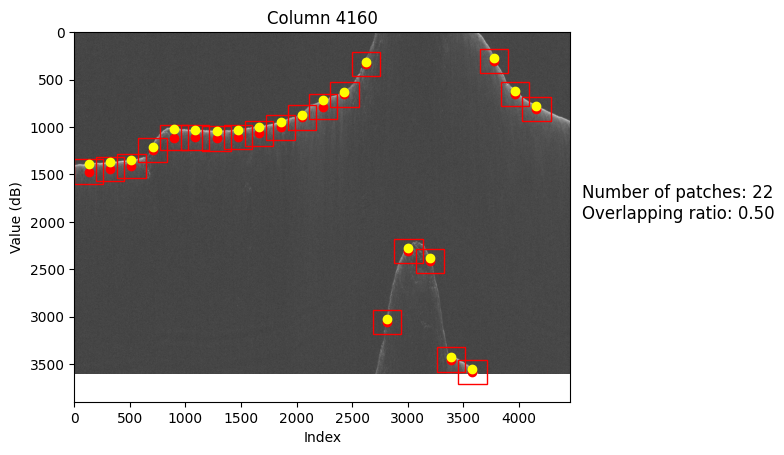

In [ ]:
# Plot over the entire horizon line
h_step = int(width*0.75)  # Step size for the center of the box
centers = np.arange(width//2, M-1-width//2, step=h_step)

# Create figure and axes
fig, ax = plt.subplots()
ax.imshow(R, cmap='gray', aspect='auto')

# Add the patch to the Axes
for x in centers:
    edges, y_current, maximum_y, minimum_y = calculate_box(x)
    # Create a rectangle patch
    rect = patches.Rectangle((edges[0], edges[2]), width, height, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    # Center of the rectangle
    center_y = edges[2]+height//2
    ax.plot(x, center_y, 'o', color='red')

    # Current horizon point
    ax.plot(x, y_current, 'o', color='yellow')

# Add text to the right of the image
plt.text(M + 100, N // 2, f"Number of patches: {len(centers)}\nOverlapping ratio: {2*(width-h_step)/width:.2f}",
        fontsize=12, color='black', verticalalignment='center')

plt.title("Patching over the horizon line")
plt.xlabel("Sample")
plt.ylabel("Line")
plt.show()